In [1]:
# imports
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load XML file
tree = ET.parse('../data/export.xml')
root = tree.getroot()

# pull out all records collected by Apple Health
records = []

for record in root.findall('Record'):
    records.append({
        'type': record.get('type'),
        'startDate': record.get('startDate'),
        'endDate': record.get('endDate'),
        'value': record.get('value')
    })

df = pd.DataFrame(records)
df.head()

,type,startDate,endDate,value
0,HKQuantityTypeIdentifierHeight,2017-02-28 18:03:12 -0600,2017-02-28 18:03:12 -0600,5.91667
1,HKQuantityTypeIdentifierHeight,2017-03-05 08:40:02 -0600,2017-03-05 08:40:02 -0600,5.91667
2,HKQuantityTypeIdentifierBodyMass,2017-02-28 18:03:12 -0600,2017-02-28 18:03:12 -0600,150
3,HKQuantityTypeIdentifierBodyMass,2017-03-05 08:40:02 -0600,2017-03-05 08:40:02 -0600,150
4,HKQuantityTypeIdentifierBodyMass,2025-10-29 13:40:00 -0600,2025-10-29 13:40:00 -0600,130


In [3]:
# filter by resting heart rate records
rhr = df[df['type'] == 'HKQuantityTypeIdentifierRestingHeartRate']

rhr['startDate'] = pd.to_datetime(rhr['startDate'])
rhr['value'] = pd.to_numeric(rhr['value'], errors='coerce')

rhr = rhr.sort_values('startDate')

# see if there is time gap (ie long period of no data)
rhr['gap'] = rhr['startDate'].diff().dt.days
large_gaps = rhr[rhr['gap'] > 30] # defining large gap as 30+ days
large_gaps.head()

# keep only most recent continuous segment
last_restart_date = large_gaps['startDate'].iloc[-1]
rhr_recent = rhr[rhr['startDate'] > last_restart_date].copy()
rhr_recent.head()


,type,startDate,endDate,value,gap
1017849,HKQuantityTypeIdentifierRestingHeartRate,2025-10-27 03:15:41-06:00,2025-10-27 21:41:47 -0600,67,0.0
1017850,HKQuantityTypeIdentifierRestingHeartRate,2025-10-28 07:34:15-06:00,2025-10-28 22:38:52 -0600,64,1.0
1017851,HKQuantityTypeIdentifierRestingHeartRate,2025-10-29 07:39:51-06:00,2025-10-29 22:22:29 -0600,65,1.0
1017852,HKQuantityTypeIdentifierRestingHeartRate,2025-10-30 07:26:52-06:00,2025-10-30 21:53:27 -0600,62,0.0
1017853,HKQuantityTypeIdentifierRestingHeartRate,2025-10-31 07:27:38-06:00,2025-10-31 22:19:54 -0600,63,1.0


In [4]:
# visualize graph
#rhr_recent.plot(x='startDate', y='value')

(array([20393., 20407., 20423., 20437., 20454., 20468., 20485., 20499.]),
 [Text(20393.0, 0, '2025-11-01'),
  Text(20407.0, 0, '2025-11-15'),
  Text(20423.0, 0, '2025-12-01'),
  Text(20437.0, 0, '2025-12-15'),
  Text(20454.0, 0, '2026-01-01'),
  Text(20468.0, 0, '2026-01-15'),
  Text(20485.0, 0, '2026-02-01'),
  Text(20499.0, 0, '2026-02-15')])

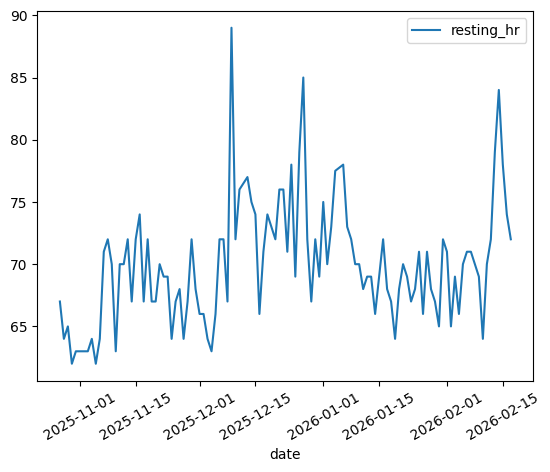

In [5]:
# daily aggregation --> 1 measurement per day
rhr_recent['date'] = rhr_recent['startDate'].dt.date

daily_rhr = (
    rhr_recent
    .groupby('date')['value']
    .mean()
    .reset_index()
)

daily_rhr.columns = ['date', 'resting_hr']
daily_rhr.plot(x='date', y='resting_hr')
plt.xticks(rotation=30)

In [6]:
# checking for missing days
daily_rhr['date'] = pd.to_datetime(daily_rhr['date'])
full_range = pd.date_range(
    start=daily_rhr['date'].min(),
    end=daily_rhr['date'].max()
)
missing_days = full_range.difference(daily_rhr['date'])
len(missing_days) # --> NOTE: 3 missing days rn will leave AS IS

3

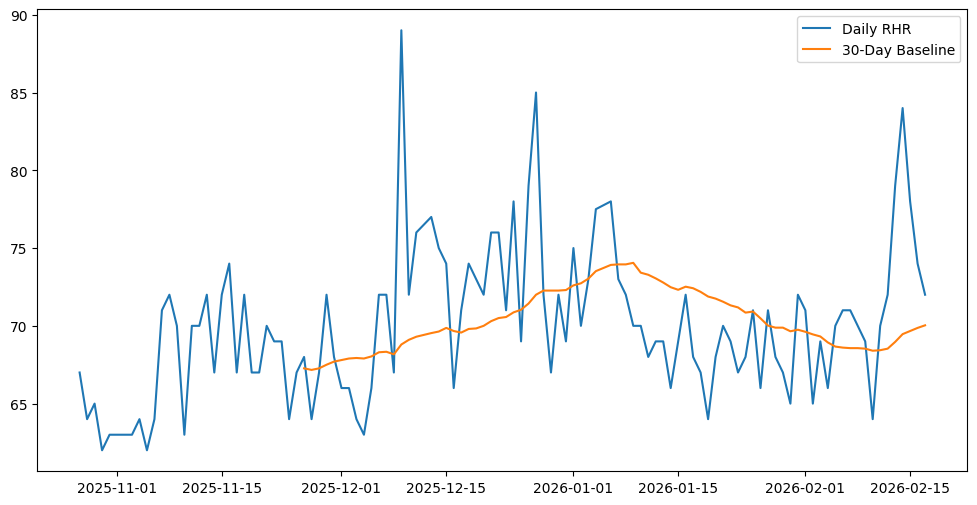

In [7]:
# compute 30 day rolling baseline
daily_rhr['baseline_30'] = (
    daily_rhr['resting_hr']
    .rolling(window=30)
    .mean()
)

# and plot
plt.figure(figsize=(12,6))
plt.plot(daily_rhr['date'], daily_rhr['resting_hr'], label='Daily RHR')
plt.plot(daily_rhr['date'], daily_rhr['baseline_30'], label='30-Day Baseline')
plt.legend()
plt.show()

In [8]:
# goal here: 'Has this person’s heart rate shifted recently relative to their own baseline?'
# compute deviation and detect sustained drift
daily_rhr['deviation'] = (
    daily_rhr['resting_hr'] - daily_rhr['baseline_30']
)

# detect over 14 days
recent_window = daily_rhr.tail(14)
mean_deviation = recent_window['deviation'].mean()
mean_deviation

np.float64(3.1976190476190474)

In [9]:
recent_window[['date', 'deviation']]

,date,deviation
97,2026-02-04,-2.933333
98,2026-02-05,1.333333
99,2026-02-06,2.400000
100,2026-02-07,2.433333
101,2026-02-08,1.433333
102,2026-02-09,0.466667
103,2026-02-10,-4.400000
104,2026-02-11,1.566667
105,2026-02-12,3.466667
106,2026-02-13,10.033333


In [10]:
# fit line to last 14 days
y = recent_window['resting_hr'].values
x = np.arange(len(y))
slope = np.polyfit(x, y, 1)[0]
slope

np.float64(0.7384615384615363)

In [11]:
# NOTE: divya thoughts:
# - 2 diff signal types: 
# --> sustained baseline shift: gradual (inc/dec) over weeks
# --> short-term elevation (as we see above due to travel 2/13 - 2/17)
# system MUST distinguish btwn these

# divya idea: later integrate travel apps...to 'know' about these 'expected' potential deviations

In [13]:
# compute 7 day rolling average to compare to 30 day baseline
daily_rhr['avg_7'] = daily_rhr['resting_hr'].rolling(7).mean()
daily_rhr['short_vs_long'] = daily_rhr['avg_7'] - daily_rhr['baseline_30']
daily_rhr.tail(10)[['date', 'short_vs_long']]

,date,short_vs_long
101,2026-02-08,0.290476
102,2026-02-09,0.895238
103,2026-02-10,0.314286
104,2026-02-11,0.852381
105,2026-02-12,1.038095
106,2026-02-13,1.747619
107,2026-02-14,3.104762
108,2026-02-15,4.047619
109,2026-02-16,4.561905
110,2026-02-17,5.538095


In [14]:
recent_window['resting_hr']

97     66.0
98     70.0
99     71.0
100    71.0
101    70.0
102    69.0
103    64.0
104    70.0
105    72.0
106    79.0
107    84.0
108    78.0
109    74.0
110    72.0
Name: resting_hr, dtype: float64

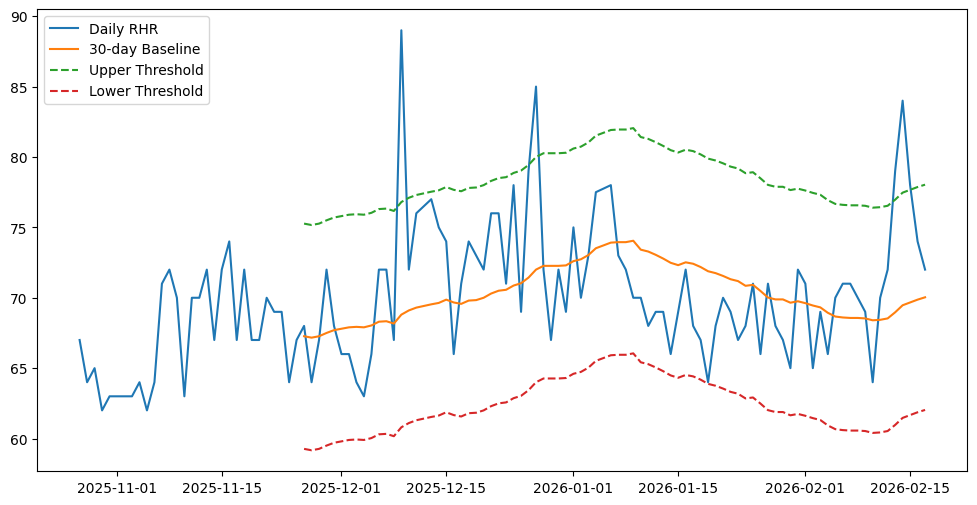

In [19]:
# specific to this data - threshold of a 'spike' @ 8 +/- deviation of HR
daily_rhr['upper_band'] = daily_rhr['baseline_30'] + 8
daily_rhr['lower_band'] = daily_rhr['baseline_30'] - 8
plt.figure(figsize=(12,6))

plt.plot(daily_rhr['date'], daily_rhr['resting_hr'], label='Daily RHR')
plt.plot(daily_rhr['date'], daily_rhr['baseline_30'], label='30-day Baseline')

plt.plot(daily_rhr['date'], daily_rhr['upper_band'], linestyle='--', label='Upper Threshold')
plt.plot(daily_rhr['date'], daily_rhr['lower_band'], linestyle='--', label='Lower Threshold')

plt.legend()
plt.show()

In [16]:
# compute rolling standard deviation (30-day)
daily_rhr['std_30'] = (
    daily_rhr['resting_hr']
    .rolling(window=30)
    .std()
)

daily_rhr['z_score'] = (
    (daily_rhr['resting_hr'] - daily_rhr['baseline_30'])
    / daily_rhr['std_30']
)
daily_rhr['anomaly'] = daily_rhr['z_score'] > 2
daily_rhr[daily_rhr['anomaly'] == True][['date','resting_hr','z_score']]

,date,resting_hr,z_score
42,2025-12-09,89.0,4.156890
59,2025-12-27,85.0,2.146207
106,2026-02-13,79.0,3.306859
107,2026-02-14,84.0,3.552095


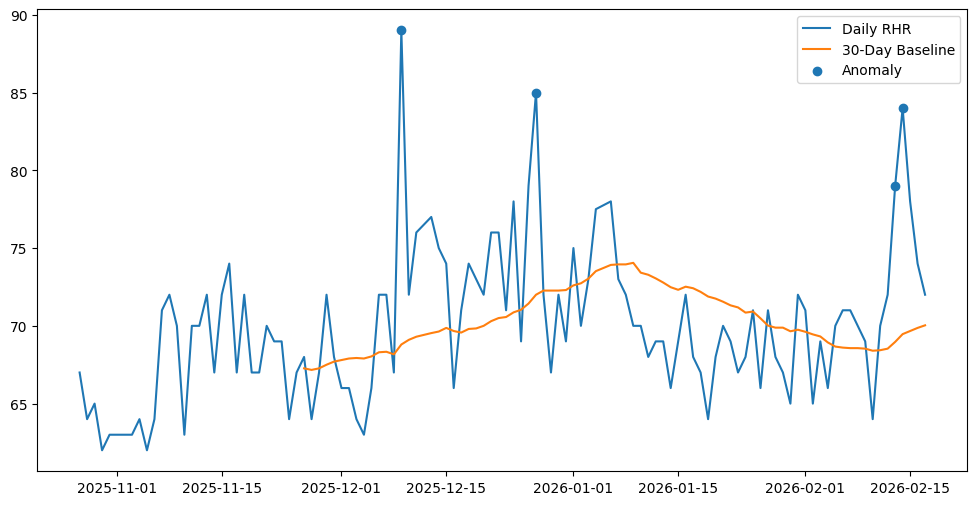

In [20]:
# plotting anomlaies
plt.figure(figsize=(12,6))

plt.plot(daily_rhr['date'], daily_rhr['resting_hr'], label='Daily RHR')
plt.plot(daily_rhr['date'], daily_rhr['baseline_30'], label='30-Day Baseline')

anomalies = daily_rhr[daily_rhr['anomaly']]

plt.scatter(anomalies['date'], anomalies['resting_hr'], label='Anomaly')

plt.legend()
plt.show()

In [28]:
hrv = df[df['type'] == 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN']

hrv['startDate'] = pd.to_datetime(hrv['startDate'])
hrv['value'] = pd.to_numeric(hrv['value'], errors='coerce')

hrv = hrv.sort_values('startDate')

hrv['date'] = hrv['startDate'].dt.date

daily_hrv = (
    hrv.groupby('date')['value']
    .mean()
    .reset_index()
)

daily_hrv.rename(columns={'value': 'hrv'}, inplace=True)

daily_hrv['baseline_30'] = (
    daily_hrv['hrv']
    .rolling(window=30)
    .mean()
)

daily_hrv['deviation'] = daily_hrv['hrv'] - daily_hrv['baseline_30']

daily_hrv['date'] = pd.to_datetime(daily_hrv['date'])
daily_rhr['date'] = pd.to_datetime(daily_rhr['date'])

combined = daily_rhr.merge(daily_hrv, on='date', how='inner')

combined.rename(columns={
    'baseline_30_x': 'rhr_baseline',
    'baseline_30_y': 'hrv_baseline'
}, inplace=True)

combined['rhr_dev'] = combined['resting_hr'] - combined['rhr_baseline']
combined['hrv_dev'] = combined['hrv'] - combined['hrv_baseline']

combined['rhr_flag'] = combined['rhr_dev'] > 5
combined['hrv_flag'] = combined['hrv_dev'] < -10

combined['drift_score'] = combined[['rhr_flag','hrv_flag']].sum(axis=1)

combined.tail(14)[['date','rhr_dev','hrv_dev','drift_score']]

,date,rhr_dev,hrv_dev,drift_score
97,2026-02-04,-2.933333,-0.638220,0
98,2026-02-05,1.333333,-5.073152,0
99,2026-02-06,2.400000,0.487962,0
100,2026-02-07,2.433333,-0.837376,0
101,2026-02-08,1.433333,-6.106455,0
102,2026-02-09,0.466667,6.279963,0
103,2026-02-10,-4.400000,-0.675741,0
104,2026-02-11,1.566667,2.029146,0
105,2026-02-12,3.466667,4.013377,0
106,2026-02-13,10.033333,-3.608576,1


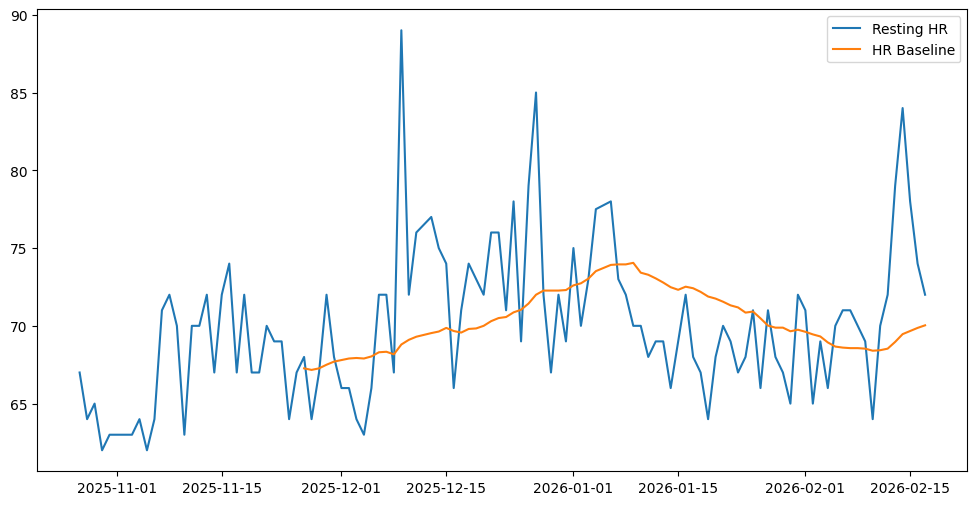

In [24]:
plt.figure(figsize=(12,6))

plt.plot(combined['date'], combined['resting_hr'], label='Resting HR')
plt.plot(combined['date'], combined['rhr_baseline'], label='HR Baseline')

plt.legend()
plt.show()

In [31]:
print(len(daily_hrv))

233


In [35]:
import xml.etree.ElementTree as ET

tree = ET.parse("../data/export.xml")
root = tree.getroot()

types = set()

for record in root.findall("Record"):
    types.add(record.attrib.get("type"))

for t in sorted(types):
    print(t)

HKCategoryTypeIdentifierAppleStandHour
HKCategoryTypeIdentifierAudioExposureEvent
HKCategoryTypeIdentifierHighHeartRateEvent
HKCategoryTypeIdentifierUnsuccessfulBloodOxygenSaturationAnalysisEvent
HKQuantityTypeIdentifierActiveEnergyBurned
HKQuantityTypeIdentifierAppleExerciseTime
HKQuantityTypeIdentifierAppleStandTime
HKQuantityTypeIdentifierAppleWalkingSteadiness
HKQuantityTypeIdentifierBasalEnergyBurned
HKQuantityTypeIdentifierBodyMass
HKQuantityTypeIdentifierDistanceWalkingRunning
HKQuantityTypeIdentifierEnvironmentalAudioExposure
HKQuantityTypeIdentifierEnvironmentalSoundReduction
HKQuantityTypeIdentifierFlightsClimbed
HKQuantityTypeIdentifierHeadphoneAudioExposure
HKQuantityTypeIdentifierHeartRate
HKQuantityTypeIdentifierHeartRateVariabilitySDNN
HKQuantityTypeIdentifierHeight
HKQuantityTypeIdentifierOxygenSaturation
HKQuantityTypeIdentifierPhysicalEffort
HKQuantityTypeIdentifierRespiratoryRate
HKQuantityTypeIdentifierRestingHeartRate
HKQuantityTypeIdentifierSixMinuteWalkTestDistan

In [ ]:
# extract hrv
def extract_hrv(df):
    hrv = df[df['type'] == 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN'].copy()
    hrv['date'] = pd.to_datetime(hrv['startDate']).dt.date
    hrv['value'] = pd.to_numeric(hrv['value'], errors='coerce')
    daily_hrv = hrv.groupby('date')['value'].mean().reset_index()
    daily_hrv.columns = ['date', 'hrv']
    daily_hrv['date'] = pd.to_datetime(daily_hrv['date'])
    return daily_hrv